# Laboratorio 7 — Spark MLlib
Jose López, Hugo Barillas y Luis Palacios

CC3066 Data Science, Universidad del Valle de Guatemala, Semestre II 2026

Este avance cubre la parte de análisis exploratorio y segmentación:

1. Carga, armonización y calidad de datos
2. Estadística descriptiva
3. Relaciones entre variables numéricas
4. Segmentación con KMeans

Se usan las bases de Personas de la ENEIC del INE. Los cuatro trimestres de 2025 se usan para desarrollar y el primer trimestre de 2026 se guarda para la prueba final.

Todo el análisis se hace con Spark. pandas solo se usa para leer los Excel y para graficar tablas resumidas o muestras pequeñas. Todas las estadísticas se calculan con los datos completos.

## 0. Configuración del ambiente

In [1]:
import os, sys, json, shutil
from pathlib import Path
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

os.environ.setdefault("PYSPARK_PYTHON", sys.executable)
os.environ.setdefault("PYSPARK_DRIVER_PYTHON", sys.executable)

from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.stat import Correlation
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

spark = (SparkSession.builder
         .appName("Lab7-ENEIC-Avance")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .config("spark.sql.execution.arrow.pyspark.enabled", "true")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

SEED = 42
BASE = Path.cwd()
DATOS = BASE / "datos"          
PARQ = BASE / "parquet"        
PARQ.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 160, "display.max_columns", 40)
print("Spark", spark.version, "| Python", sys.version.split()[0])

Spark 3.5.9 | Python 3.10.11


In [2]:
def guardar_parquet(df, ruta):
    ruta = Path(ruta)
    try:
        df.write.mode("overwrite").parquet(str(ruta))
        modo = "Spark DataFrameWriter"
    except Exception:
        import pyarrow as pa, pyarrow.parquet as pq
        if ruta.exists():
            shutil.rmtree(ruta)
        ruta.mkdir(parents=True)
        try:
            tabla = pa.Table.from_batches(df._collect_as_arrow())
        except Exception:
            tabla = pa.Table.from_pandas(df.toPandas(), preserve_index=False)
        pq.write_table(tabla, ruta / "part-00000.parquet")
        modo = "pyarrow (fallback Windows)"
    print(f"Guardado {ruta.relative_to(BASE)}  [{modo}]")

def leer_parquet(ruta, esquema=None):
    try:
        df = spark.read.parquet(str(ruta))
    except Exception:   # Windows sin winutils: se leen directamente los archivos part-*.parquet
        df = spark.read.parquet(*[str(f) for f in sorted(Path(ruta).glob("*.parquet"))])
    if esquema is not None:   # asegura exactamente los tipos declarados
        df = df.select([F.col(c.name).cast(c.dataType).alias(c.name) for c in esquema.fields])
    return df

## 1. Carga, armonización y calidad de datos

### 1.1 Archivos de origen

| Periodo | Archivo | Uso |
|---|---|---|
| 2025T1 | Personas_2025T1.xlsx | Entrenamiento |
| 2025T2 | Personas_2025T2.xlsx | Entrenamiento |
| 2025T3 | Personas_2025T3.xlsx | Entrenamiento |
| 2025T4 | Personas_2025T4.xlsx | Validación y entrenamiento final |
| 2026T1 | Personas_2026T1.xlsx | Prueba final |

El periodo de cada registro se toma del archivo del que viene y no de la columna TRIMESTRE. Esa columna se conserva sin cambios para revisión.

Cada Excel se lee por separado, se toman solo las columnas necesarias, los códigos se pasan a número y se convierte a un DataFrame de Spark con tipos definidos. Cada archivo convertido se guarda en Parquet para no volver a leer el Excel. También se guarda una huella de la fila completa para poder revisar duplicados.

In [3]:
ARCHIVOS = [
    dict(archivo_origen="Personas_2025T1.xlsx", periodo_archivo="2025T1", anio_archivo=2025, trimestre_calendario=1),
    dict(archivo_origen="Personas_2025T2.xlsx", periodo_archivo="2025T2", anio_archivo=2025, trimestre_calendario=2),
    dict(archivo_origen="Personas_2025T3.xlsx", periodo_archivo="2025T3", anio_archivo=2025, trimestre_calendario=3),
    dict(archivo_origen="Personas_2025T4.xlsx", periodo_archivo="2025T4", anio_archivo=2025, trimestre_calendario=4),
    dict(archivo_origen="Personas_2026T1.xlsx", periodo_archivo="2026T1", anio_archivo=2026, trimestre_calendario=1),
]

# Columnas originales requeridas y su tipo explícito en Spark
COLS_ORIG = {
    "ANIO": T.IntegerType(), "TRIMESTRE": T.IntegerType(), "DOMINIO": T.IntegerType(),
    "NUM_HOGAR": T.LongType(), "NUM_PERSONA": T.IntegerType(), "FACTOR": T.DoubleType(),
    "OCUPADOS": T.IntegerType(), "P02A03": T.DoubleType(), "P03A03A": T.IntegerType(),
    "P05C16": T.IntegerType(), "P05C07A": T.DoubleType(), "P05C07B": T.DoubleType(),
    "P05H01A": T.DoubleType(), "P05D01": T.DoubleType(),
}
COLS_CODIGO = [c for c, t in COLS_ORIG.items() if isinstance(t, (T.IntegerType, T.LongType))]

ESQUEMA_RAW = T.StructType(
    [T.StructField("archivo_origen", T.StringType(), False),
     T.StructField("periodo_archivo", T.StringType(), False),
     T.StructField("anio_archivo", T.IntegerType(), False),
     T.StructField("trimestre_calendario", T.IntegerType(), False)]
    + [T.StructField(c, t, True) for c, t in COLS_ORIG.items()]
    + [T.StructField("hash_fila", T.StringType(), False)]
)

def a_numero(s: pd.Series) -> pd.Series:
    # Homologa un código/valor que puede venir como número o texto (' 2', '2.0', 2) a float; texto no numérico -> NaN.
    if s.dtype == object:
        s = s.astype(str).str.strip().replace({"": None, "nan": None, "None": None})
    return pd.to_numeric(s, errors="coerce")

def convertir_excel(meta):
    # Lee UN Excel, selecciona columnas, homologa tipos y devuelve (DataFrame Spark, lista de columnas originales).
    pdf = pd.read_excel(DATOS / meta["archivo_origen"], sheet_name=0, dtype=object)
    columnas = list(pdf.columns)
    hash_fila = pd.util.hash_pandas_object(pdf.astype(str), index=False).astype(str)
    sel = pd.DataFrame({c: a_numero(pdf[c]) for c in COLS_ORIG})
    no_enteros = {c: int((sel[c].notna() & ((sel[c] % 1) != 0)).sum()) for c in COLS_CODIGO}
    assert sum(no_enteros.values()) == 0, f"Códigos no enteros: {no_enteros}"
    for c in COLS_CODIGO:                      
        sel[c] = sel[c].astype("Int64")
    sel.insert(0, "trimestre_calendario", meta["trimestre_calendario"])
    sel.insert(0, "anio_archivo", meta["anio_archivo"])
    sel.insert(0, "periodo_archivo", meta["periodo_archivo"])
    sel.insert(0, "archivo_origen", meta["archivo_origen"])
    sel["hash_fila"] = hash_fila.values
    del pdf
    sdf = spark.createDataFrame(sel, schema=ESQUEMA_RAW)
    for c, t in COLS_ORIG.items():
        if isinstance(t, T.DoubleType):
            sdf = sdf.withColumn(c, F.when(F.isnan(c), None).otherwise(F.col(c)))
    return sdf, columnas

raw, columnas_archivo = {}, {}
for meta in ARCHIVOS:
    p = meta["periodo_archivo"]
    destino, meta_json = PARQ / "raw" / p, PARQ / "raw" / f"columnas_{p}.json"
    if not (destino.exists() and meta_json.exists()):
        sdf, cols = convertir_excel(meta)
        guardar_parquet(sdf, destino)
        meta_json.write_text(json.dumps(cols))
    raw[p] = leer_parquet(destino, ESQUEMA_RAW)
    columnas_archivo[p] = json.loads(meta_json.read_text())
    print(f"{p}: {raw[p].count():>6,} registros | {len(columnas_archivo[p])} columnas originales")

2025T1: 51,588 registros | 270 columnas originales


2025T2: 51,167 registros | 270 columnas originales


2025T3: 51,583 registros | 270 columnas originales


2025T4: 49,338 registros | 302 columnas originales


2026T1: 49,843 registros | 270 columnas originales


### 1.2 Por qué IV de 2025 no puede apilarse por posición

In [4]:
ref = columnas_archivo["2025T1"]
filas = []
for p, cols in columnas_archivo.items():
    pos_ref = {c: i for i, c in enumerate(ref)}
    filas.append(dict(
        periodo_archivo=p, n_columnas=len(cols),
        mismo_orden_que_2025T1=(cols == ref),
        columnas_faltantes=len(set(ref) - set(cols)),
        columnas_nuevas=len(set(cols) - set(ref)),
        **{f"pos_{c}": cols.index(c) + 1 for c in ["P03A03A", "P05C16", "P05D01", "OCUPADOS"]},
    ))
display(pd.DataFrame(filas))
print("Columnas de 2025T1 ausentes en 2025T4:", sorted(set(ref) - set(columnas_archivo["2025T4"])))
print("Columnas nuevas en 2025T4 (primeras 15):", sorted(set(columnas_archivo["2025T4"]) - set(ref))[:15])

,periodo_archivo,n_columnas,mismo_orden_que_2025T1,columnas_faltantes,columnas_nuevas,pos_P03A03A,pos_P05C16,pos_P05D01,pos_OCUPADOS
0,2025T1,270,True,0,0,33,88,105,266
1,2025T2,270,True,0,0,33,88,105,266
2,2025T3,270,True,0,0,33,88,105,266
3,2025T4,302,False,10,42,29,81,98,298
4,2026T1,270,True,0,0,33,88,105,266


Columnas de 2025T1 ausentes en 2025T4: ['P02A01C', 'P02A01D', 'P02A01G', 'P02A01I', 'P05C01A', 'P05C02A', 'P05C04A', 'P05G01A', 'P05G02A', 'P05G04A']
Columnas nuevas en 2025T4 (primeras 15): ['P07A01A', 'P07A01B', 'P07A01C', 'P07A02A', 'P07A02B', 'P07A02C', 'P07A03A', 'P07A03B', 'P07A03C', 'P07A04A', 'P07A04B', 'P07A04C', 'P08A01A', 'P08A01B', 'P08A01C']


Los archivos de I, II y III de 2025 y el de 2026 tienen 270 columnas en el mismo orden. IV de 2025 tiene 302 columnas: agrega 42 variables nuevas, le faltan 10 y el resto queda en otras posiciones. Por ejemplo, el salario pasa de la columna 105 a la 98.

Si se apila por posición, se mezclarían variables distintas en la misma columna. Por eso se usa unionByName, que une las columnas por nombre.

### 1.3 Unión de 2025, esquema y cinco registros

Los cuatro archivos de 2025 se unen con unionByName, que empareja las columnas por nombre y no por posición.

In [5]:
PERIODOS_2025 = ["2025T1", "2025T2", "2025T3", "2025T4"]
raw_2025 = reduce(lambda a, b: a.unionByName(b), [raw[p] for p in PERIODOS_2025]).cache()
raw_2026 = raw["2026T1"].cache()

raw_2025.printSchema()
raw_2025.drop("hash_fila").show(5, truncate=False)
print(f"Registros 2025 (4 archivos unidos): {raw_2025.count():,} | 2026T1: {raw_2026.count():,}")

root
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- DOMINIO: integer (nullable = true)
 |-- NUM_HOGAR: long (nullable = true)
 |-- NUM_PERSONA: integer (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- OCUPADOS: integer (nullable = true)
 |-- P02A03: double (nullable = true)
 |-- P03A03A: integer (nullable = true)
 |-- P05C16: integer (nullable = true)
 |-- P05C07A: double (nullable = true)
 |-- P05C07B: double (nullable = true)
 |-- P05H01A: double (nullable = true)
 |-- P05D01: double (nullable = true)
 |-- hash_fila: string (nullable = true)



+--------------------+---------------+------------+--------------------+----+---------+-------+---------+-----------+------+--------+------+-------+------+-------+-------+-------+------+
|archivo_origen      |periodo_archivo|anio_archivo|trimestre_calendario|ANIO|TRIMESTRE|DOMINIO|NUM_HOGAR|NUM_PERSONA|FACTOR|OCUPADOS|P02A03|P03A03A|P05C16|P05C07A|P05C07B|P05H01A|P05D01|
+--------------------+---------------+------------+--------------------+----+---------+-------+---------+-----------+------+--------+------+-------+------+-------+-------+-------+------+
|Personas_2025T1.xlsx|2025T1         |2025        |1                   |2025|2        |2      |13796    |3          |338.0 |NULL    |14.0  |3      |NULL  |NULL   |NULL   |NULL   |NULL  |
|Personas_2025T1.xlsx|2025T1         |2025        |1                   |2025|2        |2      |13796    |1          |338.0 |1       |42.0  |5      |6     |23.0   |0.0    |35.0   |NULL  |
|Personas_2025T1.xlsx|2025T1         |2025        |1             

Registros 2025 (4 archivos unidos): 203,676 | 2026T1: 49,843


### 1.4 Periodo del archivo contra la columna TRIMESTRE

In [6]:
(raw_2025.unionByName(raw_2026)
   .groupBy("periodo_archivo", "ANIO", "TRIMESTRE").count()
   .orderBy("periodo_archivo", "TRIMESTRE").show())

+---------------+----+---------+-----+
|periodo_archivo|ANIO|TRIMESTRE|count|
+---------------+----+---------+-----+
|         2025T1|2025|        2|51588|
|         2025T2|2025|        2|  175|
|         2025T2|2025|        3|50992|
|         2025T3|2025|        4|51583|
|         2025T4|2025|        5|49338|
|         2026T1|2026|        6|49843|
+---------------+----+---------+-----+



La columna TRIMESTRE no coincide con el trimestre del calendario. Vale 2 en I de 2025, 3 en II de 2025 con 175 registros que dicen 2, 4 en III, 5 en IV y 6 en I de 2026.

Restarle uno dejaría mal asignados esos 175 registros. Por eso el periodo se toma del archivo de origen.

### 1.5 Datos faltantes antes de filtrar

In [7]:
VARS_FALT = ["P05D01", "P02A03", "P05C07A", "P05C07B", "P05H01A", "P03A03A", "P05C16", "DOMINIO",
             "OCUPADOS", "NUM_HOGAR", "NUM_PERSONA", "FACTOR", "ANIO", "TRIMESTRE"]
NOMBRE = {"P05D01": "salario_mensual", "P02A03": "edad", "P05C07A": "antiguedad_anios",
          "P05C07B": "antiguedad_meses", "P05H01A": "horas_semanales", "P03A03A": "nivel_educativo",
          "P05C16": "categoria_ocupacional", "DOMINIO": "dominio", "OCUPADOS": "ocupado"}

def tabla_faltantes(df):
    agg = df.agg(F.count(F.lit(1)).alias("n"),
                 *[F.sum(F.col(c).isNull().cast("int")).alias(c) for c in VARS_FALT]).first().asDict()
    n = agg.pop("n")
    t = pd.DataFrame({"variable": list(agg), "faltantes": list(agg.values())})
    t.insert(1, "nombre_analitico", t["variable"].map(NOMBRE).fillna("(se conserva)"))
    t["pct_faltantes"] = (100 * t["faltantes"] / n).round(2)
    return t, n

falt_2025, n25 = tabla_faltantes(raw_2025)
falt_2026, n26 = tabla_faltantes(raw_2026)
falt = falt_2025.merge(falt_2026[["variable", "faltantes", "pct_faltantes"]], on="variable", suffixes=("_2025", "_2026T1"))
print(f"n 2025 = {n25:,} | n 2026T1 = {n26:,}")
display(falt)

# Faltantes por archivo (%)
por_archivo = (raw_2025.unionByName(raw_2026).groupBy("periodo_archivo")
               .agg(*[F.round(100 * F.avg(F.col(c).isNull().cast("int")), 2).alias(c) for c in VARS_FALT[:9]])
               .orderBy("periodo_archivo").toPandas().set_index("periodo_archivo"))
display(por_archivo.rename(columns=NOMBRE))

n 2025 = 203,676 | n 2026T1 = 49,843


,variable,nombre_analitico,faltantes_2025,pct_faltantes_2025,faltantes_2026T1,pct_faltantes_2026T1
0,P05D01,salario_mensual,150651,73.97,36585,73.40
1,P02A03,edad,0,0.00,0,0.00
2,P05C07A,antiguedad_anios,115454,56.69,28109,56.40
3,P05C07B,antiguedad_meses,115454,56.69,28109,56.40
4,P05H01A,horas_semanales,115454,56.69,28109,56.40
5,P03A03A,nivel_educativo,26344,12.93,6011,12.06
6,P05C16,categoria_ocupacional,115454,56.69,28109,56.40
7,DOMINIO,dominio,0,0.00,0,0.00
8,OCUPADOS,ocupado,115454,56.69,28109,56.40
9,NUM_HOGAR,(se conserva),0,0.00,0,0.00


,salario_mensual,edad,antiguedad_anios,antiguedad_meses,horas_semanales,nivel_educativo,categoria_ocupacional,dominio,ocupado
periodo_archivo,,,,,,,,,
2025T1,73.99,0.0,56.83,56.83,56.83,13.43,56.83,0.0,56.83
2025T2,73.63,0.0,56.33,56.33,56.33,13.05,56.33,0.0,56.33
2025T3,73.93,0.0,56.63,56.63,56.63,12.69,56.63,0.0,56.63
2025T4,74.33,0.0,56.96,56.96,56.96,12.55,56.96,0.0,56.96
2026T1,73.40,0.0,56.40,56.40,56.40,12.06,56.40,0.0,56.40


Para saber si faltan datos porque la pregunta no aplicaba o porque no se respondió, se repite el conteo solo con las personas a quienes sí les aplicaba: ocupados de 15 años o más que son asalariados.

In [8]:
aplica = raw_2025.filter((F.col("P02A03") >= 15) & (F.col("OCUPADOS") == 1) & F.col("P05C16").isin(1, 2, 3, 4))
n_aplica = aplica.count()
t = (aplica.agg(*[F.sum(F.col(c).isNull().cast("int")).alias(NOMBRE[c])
                  for c in ["P05D01", "P05C07A", "P05C07B", "P05H01A", "P03A03A"]])
     .toPandas().T.rename(columns={0: "faltantes"}))
t["pct"] = (100 * t["faltantes"] / n_aplica).round(2)
print(f"Asalariados ocupados de 15+ años en 2025: {n_aplica:,}")
display(t)
print("Salario = 0 entre asalariados:", aplica.filter(F.col("P05D01") == 0).count())

Asalariados ocupados de 15+ años en 2025: 53,025


,faltantes,pct
salario_mensual,0,0.0
antiguedad_anios,0,0.0
antiguedad_meses,0,0.0
horas_semanales,0,0.0
nivel_educativo,0,0.0


Salario = 0 entre asalariados: 0


Antes de filtrar faltan muchos datos laborales: 74 % en salario y 57 % en antigüedad, horas y categoría ocupacional. El patrón es casi igual en los cinco archivos.

Esto no es un problema de calidad. Cuando se revisa solo a los asalariados de 15 años o más, no falta ningún dato de salario, antigüedad, horas ni educación, y nadie reporta salario cero.

- Dato que no aplica: la pregunta no se le hizo a esa persona porque no le correspondía. Ese vacío es correcto y no se debe rellenar.
- Dato no registrado: la pregunta sí aplicaba pero no se obtuvo respuesta. Ese sí puede sesgar resultados. En esta base no aparece entre los asalariados.

### 1.6 Validación de códigos con el diccionario

Se leen los diccionarios del INE y se comparan entre los cinco archivos. Los códigos que no estén en el diccionario o que vengan vacíos se marcan como DESCONOCIDO. El código educativo 0 significa ninguno y no se trata como faltante.

In [9]:
def categorias_diccionario(ruta, variable):
    d = pd.read_excel(ruta, header=None)
    col0 = d[0].astype(str).str.strip()
    i = col0[col0 == variable].index[-1]            # la última aparición es el bloque de categorías
    out, j = {}, i
    while j < len(d) and (j == i or pd.isna(d.iloc[j, 0])):
        if pd.notna(d.iloc[j, 1]):
            out[int(float(d.iloc[j, 1]))] = str(d.iloc[j, 2]).strip().rstrip("?")
        j += 1
    return out

DICC = {}
for meta in ARCHIVOS:
    p = meta["periodo_archivo"]
    DICC[p] = {v: categorias_diccionario(DATOS / f"Diccionario_{p}.xlsx", v) for v in ["P03A03A", "P05C16", "DOMINIO"]}
print("¿Diccionarios idénticos en los 5 archivos?", all(DICC[p] == DICC["2025T1"] for p in DICC))
for v, cats in DICC["2025T1"].items():
    print(f"{v} ({NOMBRE[v]}): {cats}")

¿Diccionarios idénticos en los 5 archivos? True
P03A03A (nivel_educativo): {0: 'NINGUNO', 1: 'PREPRIMARIA', 2: 'PRIMARIA', 3: 'BÁSICO', 4: 'DIVERSIFICADO', 5: 'SUPERIOR', 6: 'MAESTRÍA', 7: 'DOCTORADO'}
P05C16 (categoria_ocupacional): {1: 'Empleado de gobierno', 2: 'Empleado de empresa privada', 3: 'Empleado jornalero o peón', 4: 'Del servicio doméstico', 5: 'Trabajador por cuenta propia NO agrícola', 6: 'Patrón empleador (a) socio (a) NO agrícola', 7: 'Trabajador por cuenta propia agrícola', 8: 'Patrón empleador (a) socio (a) agrícola', 9: 'Trabajador No remunerado'}
DOMINIO (dominio): {1: 'Urbano Metropolitano', 2: 'Resto Urbano', 3: 'Rural Nacional'}


In [10]:
MAP_EDU = DICC["2025T1"]["P03A03A"]
MAP_CAT = {k: v for k, v in DICC["2025T1"]["P05C16"].items() if k in (1, 2, 3, 4)}   # solo asalariados
MAP_DOM = DICC["2025T1"]["DOMINIO"]

# Códigos observados que no están en el diccionario (sobre las bases completas, antes de filtros)
todo = raw_2025.unionByName(raw_2026)
for v, dic in [("P03A03A", MAP_EDU), ("P05C16", DICC["2025T1"]["P05C16"]), ("DOMINIO", MAP_DOM)]:
    obs = todo.groupBy(v).count().orderBy(v).toPandas()
    obs["en_diccionario"] = obs[v].isin(list(dic))
    print(v, "→ códigos fuera de diccionario:", obs.loc[~obs["en_diccionario"] & obs[v].notna(), v].tolist(),
          "| nulos:", int(obs.loc[obs[v].isna(), "count"].sum()))

P03A03A → códigos fuera de diccionario: [] | nulos: 32355


P05C16 → códigos fuera de diccionario: [] | nulos: 143563


DOMINIO → códigos fuera de diccionario: [] | nulos: 0


### 1.7 Filtros de población y calidad

Los filtros se aplican siempre en el mismo orden. Cada registro excluido se cuenta en el primer filtro que no cumple. Si un dato no se puede evaluar porque está vacío, se cuenta como que no cumple.

| Paso | Criterio |
|---|---|
| 1 | Edad válida y de 15 años o más |
| 2 | Ocupado |
| 3 | Asalariado, categorías 1 a 4 |
| 4 | Salario válido y mayor que cero |
| 5 | Antigüedad con años y meses registrados |
| 6 | Años de antigüedad no negativos |
| 7 | Meses enteros entre 0 y 11 |
| 8 | Antigüedad menor o igual a la edad |
| 9 | Horas registradas |
| 10 | Horas mayores que cero y hasta 168 |

In [11]:
INF = float("inf")
edad, sal, anios, meses, horas = (F.col(c) for c in ["P02A03", "P05D01", "P05C07A", "P05C07B", "P05H01A"])
antig = anios + meses / 12

PASOS = [
    ("01 Edad finita y >= 15",            edad.isNotNull() & (edad >= 15) & (edad < INF)),
    ("02 Ocupado (OCUPADOS = 1)",          F.col("OCUPADOS") == 1),
    ("03 Asalariado (P05C16 en 1-4)",      F.col("P05C16").isin(1, 2, 3, 4)),
    ("04 Salario finito y > 0",            sal.isNotNull() & (sal > 0) & (sal < INF)),
    ("05 Antigüedad evaluable",            anios.isNotNull() & meses.isNotNull()),
    ("06 Antigüedad años >= 0",            (anios >= 0) & (anios < INF)),
    ("07 Meses entero entre 0 y 11",       (meses == F.floor(meses)) & meses.between(0, 11)),
    ("08 Antigüedad <= edad",              antig <= edad),
    ("09 Horas evaluables",                horas.isNotNull()),
    ("10 Horas > 0 y <= 168",              (horas > 0) & (horas <= 168)),
]

def paso_exclusion():
    expr = F.lit(None).cast("string")
    for nombre, cond in reversed(PASOS):              # el primer criterio incumplido gana
        expr = F.when(~F.coalesce(cond, F.lit(False)), F.lit(nombre)).otherwise(expr)
    return expr

def etiquetar(col, mapa):
    m = F.create_map(*[x for k, v in mapa.items() for x in (F.lit(k), F.lit(v))])
    return F.coalesce(m[col], F.lit("DESCONOCIDO"))

def preparar(df):
    marcado = df.withColumn("paso_exclusion", paso_exclusion()).cache()
    final = (marcado.filter(F.col("paso_exclusion").isNull())
        .select(
            "archivo_origen", "periodo_archivo", "anio_archivo", "trimestre_calendario",
            "ANIO", "TRIMESTRE", "NUM_HOGAR", "NUM_PERSONA", "FACTOR",
            F.col("P05D01").alias("salario_mensual"),
            F.col("P02A03").alias("edad"),
            F.col("P05C07A").alias("antiguedad_anios"),
            F.col("P05C07B").cast("int").alias("antiguedad_meses"),
            (F.col("P05C07A") + F.col("P05C07B") / 12).alias("antiguedad"),
            F.col("P05H01A").alias("horas_semanales"),
            F.col("P03A03A").alias("nivel_educativo_cod"),
            etiquetar(F.col("P03A03A"), MAP_EDU).alias("nivel_educativo"),
            F.col("P05C16").alias("categoria_ocupacional_cod"),
            etiquetar(F.col("P05C16"), MAP_CAT).alias("categoria_ocupacional"),
            F.col("DOMINIO").alias("dominio_cod"),
            etiquetar(F.col("DOMINIO"), MAP_DOM).alias("dominio"),
            F.col("OCUPADOS").alias("ocupado"),
            "hash_fila"))
    return marcado, final

def tabla_pasos(marcado):
    t = (marcado.groupBy("periodo_archivo", F.coalesce("paso_exclusion", F.lit("zz_conservado")).alias("paso"))
         .count().toPandas().pivot(index="paso", columns="periodo_archivo", values="count").fillna(0).astype(int))
    t["TOTAL"] = t.sum(axis=1)
    t.loc["Registros originales"] = t.sum()
    orden = ["Registros originales"] + [p for p, _ in PASOS] + ["zz_conservado"]
    t = t.reindex(orden).fillna(0).astype(int).rename(index={"zz_conservado": "Registros después de filtros"})
    return t

marc_2025, prep_2025 = preparar(raw_2025)
marc_2026, prep_2026 = preparar(raw_2026)
pasos = pd.concat([tabla_pasos(marc_2025).drop(columns="TOTAL").assign(TOTAL_2025=lambda d: d.sum(axis=1)),
                   tabla_pasos(marc_2026).drop(columns="TOTAL")], axis=1)
display(pasos)

periodo_archivo,2025T1,2025T2,2025T3,2025T4,TOTAL_2025,2026T1
paso,,,,,,
Registros originales,51588,51167,51583,49338,203676,49843
01 Edad finita y >= 15,16253,15882,15767,14984,62886,14803
02 Ocupado (OCUPADOS = 1),13062,12942,13443,13121,52568,13306
03 Asalariado (P05C16 en 1-4),8854,8851,8923,8569,35197,8476
04 Salario finito y > 0,0,0,0,0,0,0
05 Antigüedad evaluable,0,0,0,0,0,0
06 Antigüedad años >= 0,0,0,0,0,0,0
07 Meses entero entre 0 y 11,0,0,0,0,0,0
08 Antigüedad <= edad,0,0,0,0,0,0


In [12]:
# Registros por archivo antes y después + tasa de conservación
resumen_arch = pasos.loc[["Registros originales", "Registros después de filtros"]].T
resumen_arch["% conservado"] = (100 * resumen_arch.iloc[:, 1] / resumen_arch.iloc[:, 0]).round(2)
display(resumen_arch)

# Distribución de categorías DESCONOCIDO en la población final
for c in ["nivel_educativo", "categoria_ocupacional", "dominio"]:
    print(c, "DESCONOCIDO:", prep_2025.filter(F.col(c) == "DESCONOCIDO").count(), "(2025) |",
          prep_2026.filter(F.col(c) == "DESCONOCIDO").count(), "(2026T1)")

paso,Registros originales,Registros después de filtros,% conservado
periodo_archivo,,,
2025T1,51588,13419,26.01
2025T2,51167,13492,26.37
2025T3,51583,13450,26.07
2025T4,49338,12664,25.67
TOTAL_2025,203676,53025,26.03
2026T1,49843,13258,26.60


nivel_educativo DESCONOCIDO: 0 (2025) | 0 (2026T1)


categoria_ocupacional DESCONOCIDO: 0 (2025) | 0 (2026T1)


dominio DESCONOCIDO: 0 (2025) | 0 (2026T1)


De 203,676 registros de 2025 quedan 53,025, que es el 26 %. Cada archivo conserva entre 25.7 % y 26.4 %, y 2026 conserva 26.6 %.

Casi todas las exclusiones vienen de los tres primeros filtros: menores de 15 años, personas no ocupadas y ocupados que no son asalariados. Los filtros de calidad no excluyeron ningún registro, porque todos los asalariados tienen datos válidos. Se dejan en el código porque son parte de la regla y se aplicarán igual a datos nuevos.

No quedan categorías DESCONOCIDO. Todos los códigos existen en el diccionario y los cinco diccionarios son iguales.

### 1.8 Unicidad de periodo, hogar y persona

Si hubiera claves repetidas, se compara la huella de la fila completa para saber si es una copia exacta o un registro en conflicto. No se usa dropDuplicates.

In [13]:
CLAVE = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]

def revisar_unicidad(df, nombre):
    g = df.groupBy(CLAVE).agg(F.count(F.lit(1)).alias("n"), F.countDistinct("hash_fila").alias("hashes"))
    dup = g.filter("n > 1")
    r = dup.agg(F.count(F.lit(1)).alias("claves_duplicadas"),
                F.coalesce(F.sum("n"), F.lit(0)).alias("registros_involucrados"),
                F.coalesce(F.sum((F.col("hashes") == 1).cast("int")), F.lit(0)).alias("claves_repeticion_exacta"),
                F.coalesce(F.sum((F.col("hashes") > 1).cast("int")), F.lit(0)).alias("claves_en_conflicto")).first()
    return dict(conjunto=nombre, registros=df.count(), claves_distintas=g.count(), **r.asDict())

display(pd.DataFrame([revisar_unicidad(raw_2025, "2025 sin filtrar"), revisar_unicidad(prep_2025, "2025 filtrado"),
                      revisar_unicidad(raw_2026, "2026T1 sin filtrar"), revisar_unicidad(prep_2026, "2026T1 filtrado")]))

,conjunto,registros,claves_distintas,claves_duplicadas,registros_involucrados,claves_repeticion_exacta,claves_en_conflicto
0,2025 sin filtrar,203676,203676,0,0,0,0
1,2025 filtrado,53025,53025,0,0,0,0
2,2026T1 sin filtrar,49843,49843,0,0,0,0
3,2026T1 filtrado,13258,13258,0,0,0,0


In [14]:
# Misma persona (NUM_HOGAR, NUM_PERSONA) en varios períodos: evidencia del diseño longitudinal con rotación
apariciones = (prep_2025.groupBy("NUM_HOGAR", "NUM_PERSONA").agg(F.countDistinct("periodo_archivo").alias("periodos"))
               .groupBy("periodos").count().orderBy("periodos").toPandas())
apariciones["pct"] = (100 * apariciones["count"] / apariciones["count"].sum()).round(2)
print("Número de períodos en que aparece cada par (NUM_HOGAR, NUM_PERSONA) en la base filtrada 2025:")
display(apariciones)

# ¿Coinciden edad y dominio entre apariciones? (un control de consistencia de la identificación)
w = (prep_2025.groupBy("NUM_HOGAR", "NUM_PERSONA")
     .agg(F.countDistinct("periodo_archivo").alias("periodos"), (F.max("edad") - F.min("edad")).alias("rango_edad"),
          F.countDistinct("dominio").alias("dominios"))
     .filter("periodos > 1"))
w.select(F.count(F.lit(1)).alias("pares_repetidos"),
         F.round(F.avg((F.col("rango_edad") <= 1).cast("int")) * 100, 1).alias("pct_edad_consistente(<=1 año)"),
         F.round(F.avg((F.col("dominios") == 1).cast("int")) * 100, 1).alias("pct_mismo_dominio")).show()

Número de períodos en que aparece cada par (NUM_HOGAR, NUM_PERSONA) en la base filtrada 2025:


,periodos,count,pct
0,1,11303,42.32
1,2,7831,29.32
2,3,4240,15.87
3,4,3335,12.49


+---------------+-----------------------------+-----------------+
|pares_repetidos|pct_edad_consistente(<=1 año)|pct_mismo_dominio|
+---------------+-----------------------------+-----------------+
|          15406|                         99.6|            100.0|
+---------------+-----------------------------+-----------------+



No hay claves repetidas, ni en los datos completos ni en los filtrados.

La misma persona sí aparece en varios trimestres. El 57.7 % aparece en dos o más periodos y el 12.5 % en los cuatro. En esos casos la edad cambia a lo mucho un año en el 99.6 % y el dominio es el mismo siempre, lo que confirma que es la misma persona observada otra vez.

### 1.9 Guardado en Parquet

In [15]:
guardar_parquet(prep_2025, PARQ / "eneic_2025_preparado")
guardar_parquet(prep_2026, PARQ / "eneic_2026T1_preparado")

ESQ_PREP = prep_2025.schema
df25 = leer_parquet(PARQ / "eneic_2025_preparado", ESQ_PREP).cache()
df26 = leer_parquet(PARQ / "eneic_2026T1_preparado", ESQ_PREP).cache()
print(f"2025 preparado: {df25.count():,} registros | 2026T1 preparado: {df26.count():,} registros")
df25.printSchema()

Guardado parquet\eneic_2025_preparado  [pyarrow (fallback Windows)]


Guardado parquet\eneic_2026T1_preparado  [pyarrow (fallback Windows)]


2025 preparado: 53,025 registros | 2026T1 preparado: 13,258 registros
root
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- NUM_HOGAR: long (nullable = true)
 |-- NUM_PERSONA: integer (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: integer (nullable = true)
 |-- antiguedad: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo_cod: integer (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_ocupacional_cod: integer (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- dominio_cod: integer (nullable = true)
 |-- domini

### 1.10 Para qué sirve FACTOR

FACTOR indica a cuántas personas del país representa cada registro. El análisis principal no lo usa. Esta tabla solo muestra cuánto cambian los porcentajes por dominio cuando se usa.

In [16]:
ilus = (df25.groupBy("dominio").agg(F.count(F.lit(1)).alias("registros"), F.sum("FACTOR").alias("suma_factor"))
        .toPandas().set_index("dominio").reindex(["Urbano Metropolitano", "Resto Urbano", "Rural Nacional"]))
ilus["%_no_ponderado"] = (100 * ilus["registros"] / ilus["registros"].sum()).round(1)
ilus["%_ponderado_FACTOR"] = (100 * ilus["suma_factor"] / ilus["suma_factor"].sum()).round(1)
display(ilus)
print("Suma de FACTOR por trimestre (asalariados con salario positivo que representaría cada corte):")
display(df25.groupBy("periodo_archivo").agg(F.count(F.lit(1)).alias("registros"),
        F.round(F.sum("FACTOR")).alias("suma_factor")).orderBy("periodo_archivo").toPandas())

,registros,suma_factor,%_no_ponderado,%_ponderado_FACTOR
dominio,,,,
Urbano Metropolitano,22072,4842629.0,41.6,25.6
Resto Urbano,20146,7217168.0,38.0,38.1
Rural Nacional,10807,6879534.0,20.4,36.3


Suma de FACTOR por trimestre (asalariados con salario positivo que representaría cada corte):


,periodo_archivo,registros,suma_factor
0,2025T1,13419,4715485.0
1,2025T2,13492,4787795.0
2,2025T3,13450,4713724.0
3,2025T4,12664,4722327.0


### 1.11 Respuestas de la actividad 1

Por qué IV de 2025 no puede apilarse por posición

Tiene 302 columnas en lugar de 270 y las variables están en otras posiciones. Apilar por posición mezclaría datos distintos. unionByName lo evita.

Diferencia entre un dato que no aplica y una respuesta no registrada

Un dato que no aplica es un vacío esperado porque la pregunta no le correspondía a esa persona. No hay nada que recuperar. Una respuesta no registrada es cuando la pregunta sí aplicaba pero no se obtuvo. Aquí el 74 % de salarios vacíos es del primer tipo y entre los asalariados no hay del segundo.

Por qué una persona observada en dos periodos no se elimina como duplicado

Cada fila es la persona en un trimestre distinto, con su salario y condiciones de ese momento. No es una copia. Eliminarla quitaría información real. Hay que tomar en cuenta que la misma persona puede quedar en entrenamiento y en validación, lo que puede hacer que la validación salga un poco mejor de lo real.

Por qué la base filtrada no representa a todos los trabajadores del país

- Solo incluye asalariados con salario positivo. Deja fuera al 40 % de los ocupados, que trabajan por cuenta propia, son patronos o no reciben pago.
- No se usa FACTOR. El área rural es el 20 % de los registros pero representa el 36 % de los asalariados del país.
- Una misma persona aparece varias veces, así que el número de filas no es el número de personas.

Para hablar de todo el país habría que usar FACTOR en los cálculos.

## 2. Estadística descriptiva

Todas las estadísticas se calculan con Spark sobre todos los registros de 2025.

In [17]:
NUM = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]

def resumen_numerico(df, cols):
    filas = []
    for c in cols:
        r = df.agg(F.count(c).alias("n"), F.mean(c).alias("media"), F.stddev(c).alias("desv_est"),
                   F.min(c).alias("min"), F.max(c).alias("max"), F.skewness(c).alias("asimetria"),
                   F.expr(f"percentile({c}, array(0.25, 0.5, 0.75, 0.95))").alias("p")).first()
        filas.append(dict(variable=c, n=r["n"], media=r["media"], mediana=r["p"][1], desv_est=r["desv_est"],
                          min=r["min"], p25=r["p"][0], p75=r["p"][2], p95=r["p"][3], max=r["max"],
                          asimetria=r["asimetria"]))
    return pd.DataFrame(filas).set_index("variable")

desc_2025 = resumen_numerico(df25, NUM)
display(desc_2025.round(2))

,n,media,mediana,desv_est,min,p25,p75,p95,max,asimetria
variable,,,,,,,,,,
salario_mensual,53025,3421.68,3000.0,2902.11,1.0,1800.0,4000.0,8000.0,99000.0,6.00
edad,53025,35.19,33.0,13.52,15.0,24.0,44.0,61.0,89.0,0.74
antiguedad,53025,5.56,2.0,7.83,0.0,0.5,7.0,22.0,70.0,2.40
horas_semanales,53025,46.31,45.0,18.63,1.0,40.0,55.0,80.0,126.0,0.59


### 2.1 Distribución por categoría ocupacional, nivel educativo y dominio

categoria_ocupacional


,count,pct
categoria_ocupacional,,
Empleado de gobierno,6575,12.40
Empleado de empresa privada,28702,54.13
Empleado jornalero o peón,13842,26.10
Del servicio doméstico,3906,7.37


nivel_educativo


,count,pct
nivel_educativo,,
NINGUNO,3995,7.53
PREPRIMARIA,459,0.87
PRIMARIA,15822,29.84
BÁSICO,8249,15.56
DIVERSIFICADO,16851,31.78
SUPERIOR,6818,12.86
MAESTRÍA,771,1.45
DOCTORADO,60,0.11


dominio


,count,pct
dominio,,
Urbano Metropolitano,22072,41.63
Resto Urbano,20146,37.99
Rural Nacional,10807,20.38


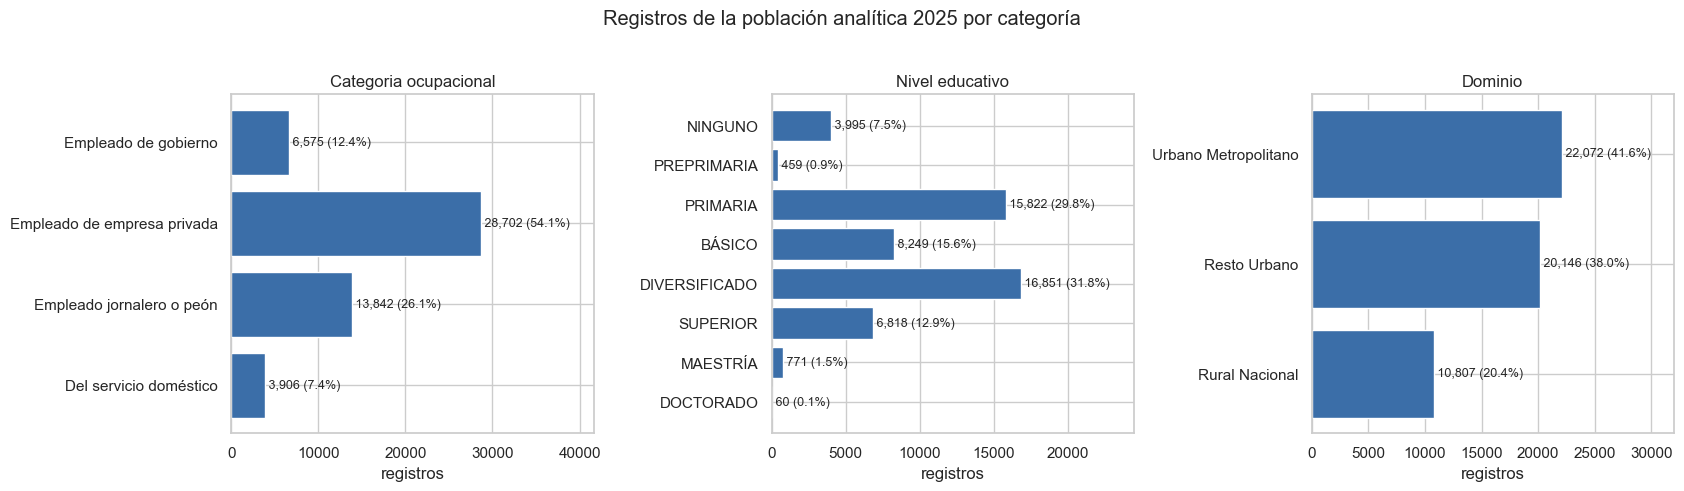

In [18]:
ORDEN_EDU = [MAP_EDU[k] for k in sorted(MAP_EDU)] + ["DESCONOCIDO"]
ORDEN_CAT = [MAP_CAT[k] for k in sorted(MAP_CAT)]
ORDEN_DOM = [MAP_DOM[k] for k in sorted(MAP_DOM)]

def conteo(df, col, orden):
    t = df.groupBy(col).count().toPandas().set_index(col).reindex(orden).dropna()
    t["count"] = t["count"].astype(int)
    t["pct"] = 100 * t["count"] / t["count"].sum()
    return t

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, (col, orden) in zip(axes, [("categoria_ocupacional", ORDEN_CAT), ("nivel_educativo", ORDEN_EDU),
                                    ("dominio", ORDEN_DOM)]):
    t = conteo(df25, col, orden)
    ax.barh(t.index, t["count"], color="#3b6ea8")
    for i, (n, p) in enumerate(zip(t["count"], t["pct"])):
        ax.text(n, i, f" {int(n):,} ({p:.1f}%)", va="center", fontsize=9)
    ax.invert_yaxis(); ax.set_title(col.replace("_", " ").capitalize()); ax.set_xlabel("registros")
    ax.set_xlim(0, t["count"].max() * 1.45)
    print(col); display(t.round(2))
plt.suptitle("Registros de la población analítica 2025 por categoría", y=1.02)
plt.tight_layout(); plt.show()

- Categoría ocupacional: más de la mitad trabaja en empresa privada, 54 %. Luego vienen jornaleros con 26 %, gobierno con 12 % y servicio doméstico con 7 %.
- Nivel educativo: lo más común es diversificado con 32 % y primaria con 30 %. Preprimaria, maestría y doctorado tienen muy pocos registros.
- Dominio: 42 % es urbano metropolitano, 38 % resto urbano y 20 % rural.

### 2.2 Forma de la distribución del salario, media y mediana

El histograma de la derecha usa escala logarítmica. Para el modelado el salario se mantiene en quetzales.

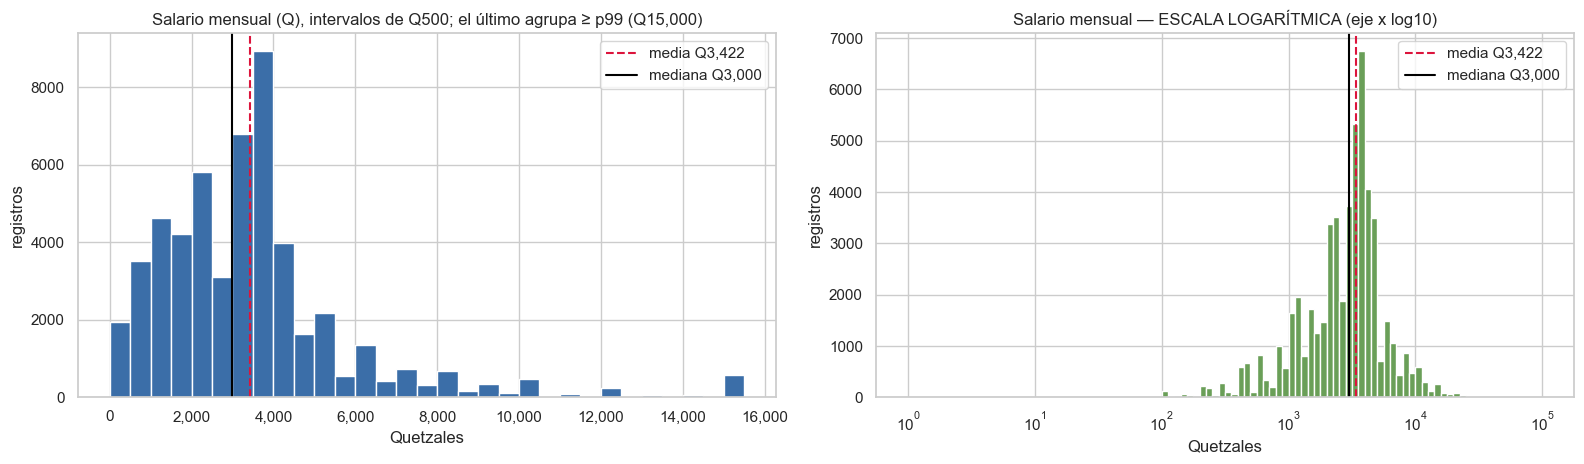

Media Q3,421.68 | Mediana Q3,000.00 | Diferencia Q421.68 (14.1% sobre la mediana) | asimetría 6.00


Registros > Q20,000: 145 | < Q500: 1946 | p99, p99.9: [15000.0, 30000.0]


+---------------+---------------+----+---------------+---------------+---------------------------+--------------------+
|periodo_archivo|salario_mensual|edad|horas_semanales|nivel_educativo|categoria_ocupacional      |dominio             |
+---------------+---------------+----+---------------+---------------+---------------------------+--------------------+
|2025T1         |99000.0        |63.0|54.0           |SUPERIOR       |Empleado de empresa privada|Urbano Metropolitano|
|2025T2         |99000.0        |64.0|54.0           |SUPERIOR       |Empleado de empresa privada|Urbano Metropolitano|
|2025T3         |99000.0        |64.0|44.0           |SUPERIOR       |Empleado de empresa privada|Urbano Metropolitano|
|2025T1         |70000.0        |43.0|50.0           |MAESTRÍA       |Empleado de empresa privada|Urbano Metropolitano|
|2025T3         |60000.0        |73.0|40.0           |SUPERIOR       |Empleado de gobierno       |Urbano Metropolitano|
|2025T4         |60000.0        |73.0|40

In [19]:
ANCHO = 500
p99 = df25.agg(F.expr("percentile(salario_mensual, 0.99)")).first()[0]
lin = (df25.withColumn("bin", F.floor(F.least(F.col("salario_mensual"), F.lit(p99)) / ANCHO) * ANCHO)
       .groupBy("bin").count().orderBy("bin").toPandas())
logb = (df25.withColumn("bin", F.floor(F.log10("salario_mensual") * 20) / 20)
        .groupBy("bin").count().orderBy("bin").toPandas())

media, mediana = desc_2025.loc["salario_mensual", ["media", "mediana"]]
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
axes[0].bar(lin["bin"], lin["count"], width=ANCHO, align="edge", color="#3b6ea8")
axes[0].set_title(f"Salario mensual (Q), intervalos de Q{ANCHO}; el último agrupa ≥ p99 (Q{p99:,.0f})")
axes[1].bar(10 ** logb["bin"], logb["count"], width=10 ** (logb["bin"] + 0.05) - 10 ** logb["bin"], align="edge",
            color="#6a9f58")
axes[1].set_xscale("log"); axes[1].set_title("Salario mensual — ESCALA LOGARÍTMICA (eje x log10)")
for ax in axes:
    ax.axvline(media, color="crimson", ls="--", label=f"media Q{media:,.0f}")
    ax.axvline(mediana, color="black", ls="-", label=f"mediana Q{mediana:,.0f}")
    ax.set_xlabel("Quetzales"); ax.set_ylabel("registros"); ax.legend()
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

print(f"Media Q{media:,.2f} | Mediana Q{mediana:,.2f} | Diferencia Q{media - mediana:,.2f} "
      f"({100 * (media / mediana - 1):.1f}% sobre la mediana) | asimetría {desc_2025.loc['salario_mensual', 'asimetria']:.2f}")
colas = df25.agg(F.sum((F.col("salario_mensual") > 20000).cast("int")).alias("mayor_20k"),
                 F.sum((F.col("salario_mensual") < 500).cast("int")).alias("menor_500"),
                 F.expr("percentile(salario_mensual, array(0.99, 0.999))").alias("p99_p999")).first()
print("Registros > Q20,000:", colas["mayor_20k"], "| < Q500:", colas["menor_500"], "| p99, p99.9:", colas["p99_p999"])
df25.orderBy(F.desc("salario_mensual")).select("periodo_archivo", "salario_mensual", "edad", "horas_semanales",
    "nivel_educativo", "categoria_ocupacional", "dominio").show(8, truncate=False)

El salario no es simétrico. La mayoría gana entre Q1,800 y Q4,000, pero hay pocos salarios muy altos que llegan hasta Q99,000. También se ve que muchas personas reportan montos redondos.

La media es Q3,422 y la mediana Q3,000. La media es 14 % mayor porque los salarios altos la jalan hacia arriba. La mediana describe mejor el salario típico.

Los salarios altos se mantienen porque son posibles y su efecto se revisará en el modelado.

### 2.3 Salario mediano por nivel educativo y categoría ocupacional

,n,mediana,media,p25,p75
nivel_educativo,,,,,
NINGUNO,3995,1500.0,1767.0,800.0,2400.0
PREPRIMARIA,459,2160.0,2242.0,1200.0,3000.0
PRIMARIA,15822,2200.0,2308.0,1200.0,3200.0
BÁSICO,8249,2800.0,2730.0,1600.0,3600.0
DIVERSIFICADO,16851,3600.0,3796.0,2800.0,4250.0
SUPERIOR,6818,5000.0,5965.0,3600.0,7500.0
MAESTRÍA,771,10000.0,11409.0,6000.0,15000.0
DOCTORADO,60,12000.0,14452.0,6000.0,21000.0


,n,mediana,media,p25,p75
categoria_ocupacional,,,,,
Empleado de gobierno,6575,5000.0,5972.0,3750.0,7380.0
Empleado de empresa privada,28702,3568.0,3875.0,2800.0,4000.0
Empleado jornalero o peón,13842,1800.0,1879.0,1000.0,2490.0
Del servicio doméstico,3906,1000.0,1266.0,600.0,1600.0


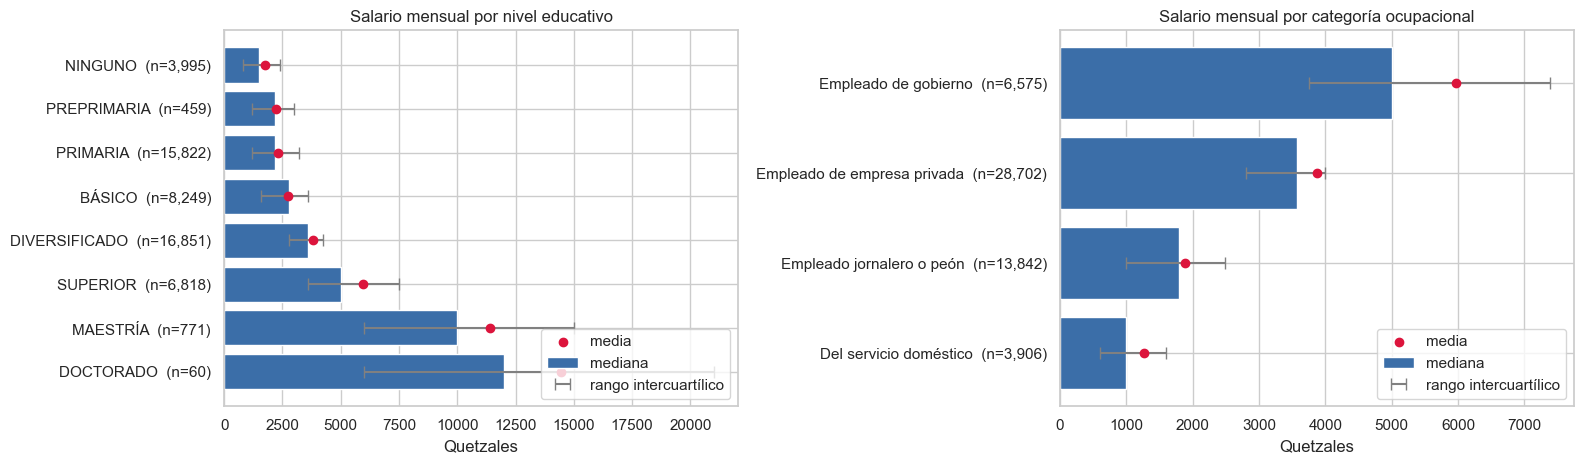

In [20]:
def mediana_por(df, col, orden):
    t = (df.groupBy(col).agg(F.count(F.lit(1)).alias("n"),
                             F.expr("percentile(salario_mensual, 0.5)").alias("mediana"),
                             F.mean("salario_mensual").alias("media"),
                             F.expr("percentile(salario_mensual, array(0.25, 0.75))").alias("q"))
         .toPandas().set_index(col).reindex(orden).dropna(subset=["n"]))
    t["n"] = t["n"].astype(int)
    t["p25"] = t["q"].str[0]; t["p75"] = t["q"].str[1]
    return t.drop(columns="q")

med_edu = mediana_por(df25, "nivel_educativo", ORDEN_EDU)
med_cat = mediana_por(df25, "categoria_ocupacional", ORDEN_CAT)
display(med_edu.round(0)); display(med_cat.round(0))

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
for ax, t, titulo in [(axes[0], med_edu, "nivel educativo"), (axes[1], med_cat, "categoría ocupacional")]:
    y = np.arange(len(t))
    ax.barh(y, t["mediana"], color="#3b6ea8", label="mediana")
    ax.errorbar(t["mediana"], y, xerr=[t["mediana"] - t["p25"], t["p75"] - t["mediana"]], fmt="none",
                ecolor="gray", capsize=4, label="rango intercuartílico")
    ax.scatter(t["media"], y, color="crimson", zorder=3, label="media")
    ax.set_yticks(y, [f"{i}  (n={int(n):,})" for i, n in zip(t.index, t["n"])]); ax.invert_yaxis()
    ax.set_title(f"Salario mensual por {titulo}"); ax.set_xlabel("Quetzales"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

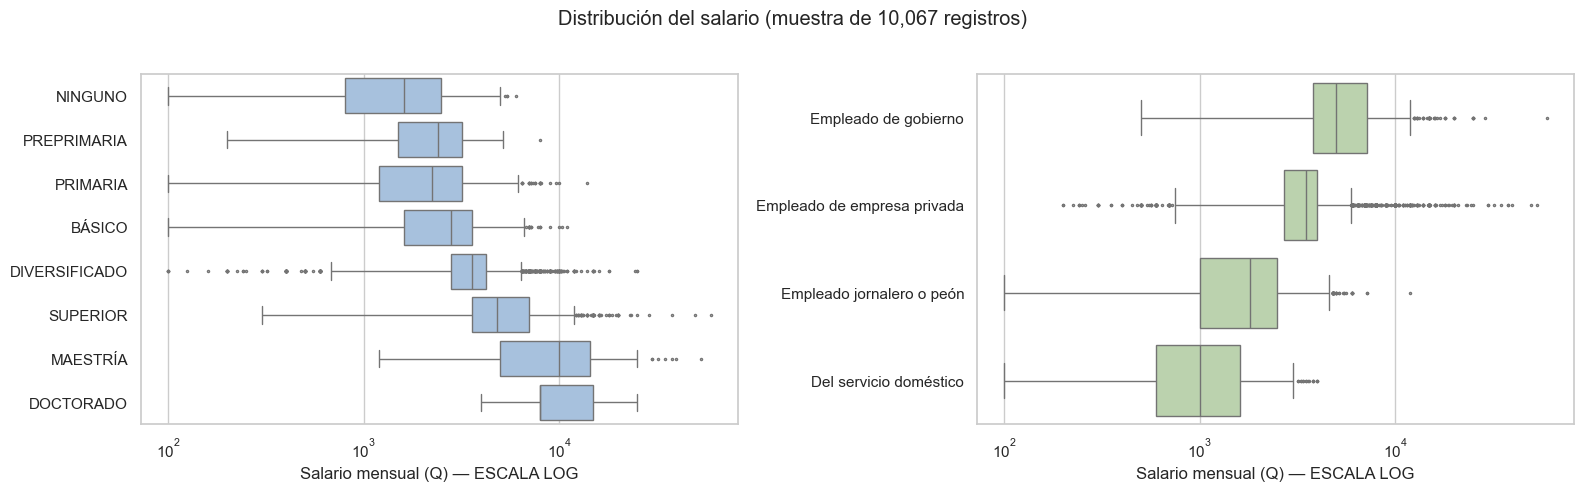

In [21]:
# Complemento visual: diagrama de caja con una MUESTRA de ~10,000 registros (solo para graficar), escala log
frac = min(1.0, 10000 / df25.count())
muestra = df25.sample(fraction=frac, seed=SEED).select("salario_mensual", "nivel_educativo",
                                                         "categoria_ocupacional").toPandas()
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
sns.boxplot(data=muestra, y="nivel_educativo", x="salario_mensual", order=[o for o in ORDEN_EDU if o in set(muestra.nivel_educativo)],
            ax=axes[0], color="#9ec1e6", fliersize=1.5)
sns.boxplot(data=muestra, y="categoria_ocupacional", x="salario_mensual", order=ORDEN_CAT, ax=axes[1],
            color="#b9d8a8", fliersize=1.5)
for ax in axes:
    ax.set_xscale("log"); ax.set_xlabel("Salario mensual (Q) — ESCALA LOG"); ax.set_ylabel("")
plt.suptitle(f"Distribución del salario (muestra de {len(muestra):,} registros)", y=1.02)
plt.tight_layout(); plt.show()

- Educación: el salario mediano sube con cada nivel, desde Q1,500 sin estudios hasta Q5,000 con universidad y Q10,000 o más con maestría o doctorado.
- Categoría: gobierno tiene la mediana más alta con Q5,000, luego empresa privada con Q3,568, jornaleros con Q1,800 y servicio doméstico con Q1,000.

Esto muestra una relación, no una causa. Educación y categoría están relacionadas entre sí.

### 2.4 Cambios entre trimestres

,n,mediana,media,n_originales,% conservado
periodo_archivo,,,,,
2025T1,13419,3000.0,3315.6,51588,26.0
2025T2,13492,3000.0,3364.6,51167,26.4
2025T3,13450,3200.0,3469.1,51583,26.1
2025T4,12664,3200.0,3544.6,49338,25.7
2026T1,13258,3200.0,3565.8,49843,26.6


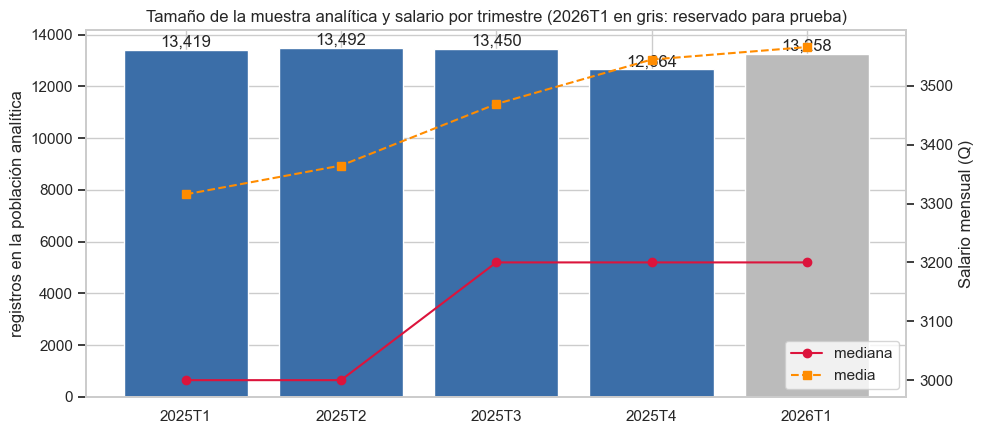

In [22]:
trim = (df25.unionByName(df26).groupBy("periodo_archivo")
        .agg(F.count(F.lit(1)).alias("n"), F.expr("percentile(salario_mensual, 0.5)").alias("mediana"),
             F.mean("salario_mensual").alias("media"))
        .orderBy("periodo_archivo").toPandas().set_index("periodo_archivo"))
trim["n_originales"] = pasos.loc["Registros originales", trim.index].values
trim["% conservado"] = 100 * trim["n"] / trim["n_originales"]
display(trim.round(1))

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.bar(trim.index, trim["n"], color=["#3b6ea8"] * 4 + ["#bbbbbb"])
ax1.set_ylabel("registros en la población analítica")
for i, n in enumerate(trim["n"]):
    ax1.text(i, n, f"{n:,}", ha="center", va="bottom")
ax2 = ax1.twinx()
ax2.plot(trim.index, trim["mediana"], "o-", color="crimson", label="mediana")
ax2.plot(trim.index, trim["media"], "s--", color="darkorange", label="media")
ax2.set_ylabel("Salario mensual (Q)"); ax2.legend(loc="lower right"); ax2.grid(False)
ax1.set_title("Tamaño de la muestra analítica y salario por trimestre (2026T1 en gris: reservado para prueba)")
plt.tight_layout(); plt.show()

El tamaño de la muestra es estable, cerca de 13,000 registros por trimestre. El salario mediano sube de Q3,000 en los primeros dos trimestres a Q3,200 desde el tercero y se mantiene en 2026. Un modelo entrenado con todo 2025 podría quedarse un poco corto con los salarios de 2026.

### 2.5 Respuestas de la actividad 2

- Distribución: predominan empresa privada, los niveles diversificado y primaria, y las zonas urbanas.
- Simetría: el salario no es simétrico, tiene una cola larga de salarios altos.
- Media y mediana: Q3,422 contra Q3,000. La media es mayor por los salarios altos. La antigüedad muestra lo mismo: la mitad lleva dos años o menos en su trabajo.
- Salario por grupo: sube con la educación y es más alto en gobierno.
- Trimestres: la muestra es estable y el salario mediano sube un poco desde el tercer trimestre.

## 3. Relaciones entre variables numéricas

Se calcula la correlación de Pearson con VectorAssembler y Correlation.corr sobre todos los registros de 2025. Se agrega Spearman como apoyo porque no se ve tan afectada por los salarios extremos.

Matriz de correlación de Pearson (n = 53,025)


,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.000,0.147,0.180,0.076
edad,0.147,1.000,0.487,-0.105
antiguedad,0.180,0.487,1.000,-0.062
horas_semanales,0.076,-0.105,-0.062,1.000


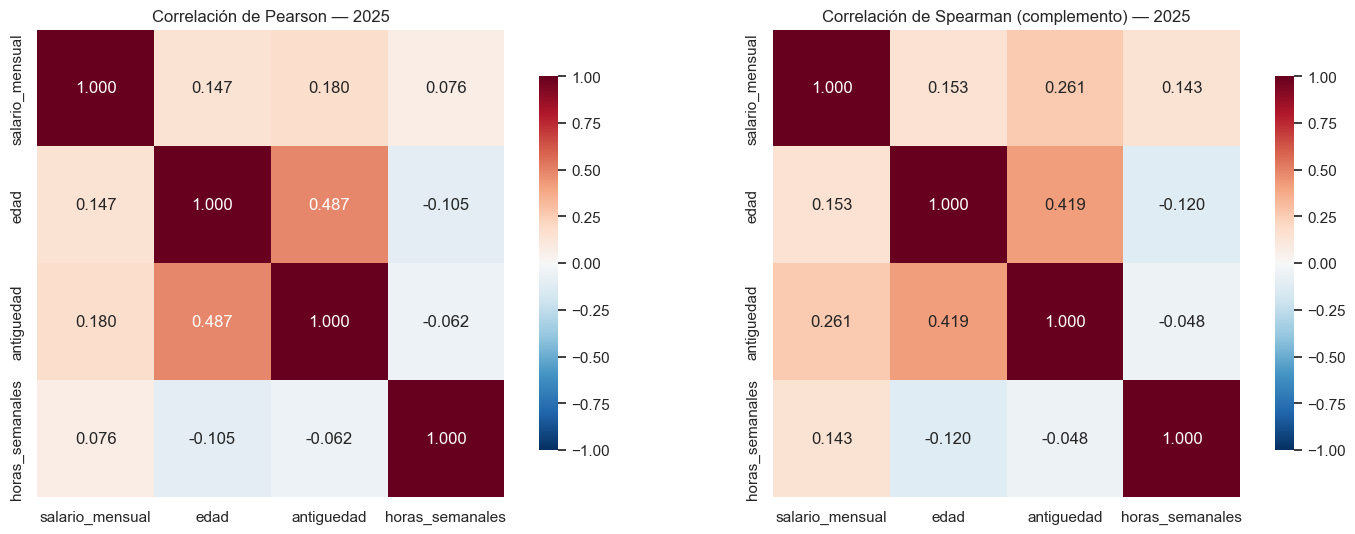

In [23]:
vec = VectorAssembler(inputCols=NUM, outputCol="vars_num").transform(df25).select("vars_num")
pearson = pd.DataFrame(Correlation.corr(vec, "vars_num", "pearson").head()[0].toArray(), index=NUM, columns=NUM)
spearman = pd.DataFrame(Correlation.corr(vec, "vars_num", "spearman").head()[0].toArray(), index=NUM, columns=NUM)
print("Matriz de correlación de Pearson (n =", f"{df25.count():,})"); display(pearson.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, m, t in [(axes[0], pearson, "Pearson"), (axes[1], spearman, "Spearman (complemento)")]:
    sns.heatmap(m, annot=True, fmt=".3f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, ax=ax,
                cbar_kws={"shrink": .8})
    ax.set_title(f"Correlación de {t} — 2025")
plt.tight_layout(); plt.show()

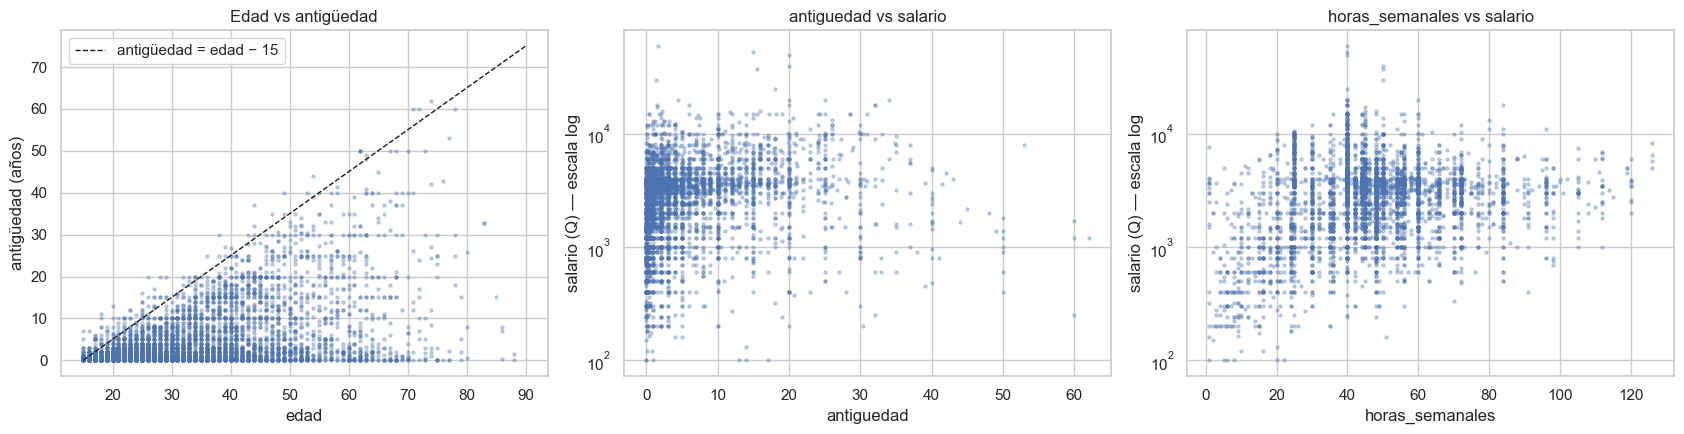

In [24]:
# Evidencia visual de la relación edad–antigüedad y salario–variables (muestra de 5,000 puntos, solo para graficar)
m = df25.sample(fraction=min(1.0, 5000 / df25.count()), seed=SEED).select(*NUM).toPandas()
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
axes[0].scatter(m["edad"], m["antiguedad"], s=5, alpha=.3)
axes[0].plot([15, 90], [0, 75], "k--", lw=1, label="antigüedad = edad − 15")
axes[0].set(xlabel="edad", ylabel="antigüedad (años)", title="Edad vs antigüedad"); axes[0].legend()
for ax, c in zip(axes[1:], ["antiguedad", "horas_semanales"]):
    ax.scatter(m[c], m["salario_mensual"], s=5, alpha=.3); ax.set_yscale("log")
    ax.set(xlabel=c, ylabel="salario (Q) — escala log", title=f"{c} vs salario")
plt.tight_layout(); plt.show()

Qué variables tienen mayor relación con el salario

Todas las relaciones con el salario son débiles. La más alta es antigüedad con 0.18, luego edad con 0.15 y horas con 0.08. Ninguna variable numérica explica mucho del salario por sí sola. Spearman da valores algo mayores, lo que indica que los salarios extremos debilitan la relación lineal. La educación y la categoría ocupacional parecen pesar más.

Relación entre edad y antigüedad

Sí hay relación, es la más fuerte de la tabla con 0.49. Tiene sentido porque las personas mayores han tenido más tiempo para acumular antigüedad. Aun así hay mucha variación, porque muchas personas mayores llevan poco tiempo en su trabajo actual. Las dos variables se pueden usar juntas en los modelos.